In [1]:
from sklearn.model_selection import train_test_split
import os, shutil, random


In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

BASE_DIR = "Blood cell Cancer [ALL]"   # input folder
OUT_DIR  = "dataset"                  # output folder (will be created)

# Create train/test folders
for split in ["train", "test"]:
    os.makedirs(os.path.join(OUT_DIR, split), exist_ok=True)

# Detect class folders
classes = [
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
]

print("Detected classes:", classes)

for cls in classes:
    cls_path = os.path.join(BASE_DIR, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if len(images) == 0:
        print(f"⚠️ No images found in {cls}")
        continue

    train_imgs, test_imgs = train_test_split(
        images,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    for split, files in zip(["train", "test"], [train_imgs, test_imgs]):
        split_cls_dir = os.path.join(OUT_DIR, split, cls)
        os.makedirs(split_cls_dir, exist_ok=True)

        for img in files:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(split_cls_dir, img)
            )

print("✅ Train/Test split completed successfully")

Detected classes: ['Benign', '[Malignant] early Pre-B', '[Malignant] Pre-B', '[Malignant] Pro-B']
✅ Train/Test split completed successfully


In [3]:
for split in ["train", "test"]:
    print(f"\n{split.upper()}")
    for cls in classes:
        path = os.path.join(OUT_DIR, split, cls)
        print(cls, ":", len(os.listdir(path)))



TRAIN
Benign : 409
[Malignant] early Pre-B : 783
[Malignant] Pre-B : 764
[Malignant] Pro-B : 636

TEST
Benign : 103
[Malignant] early Pre-B : 196
[Malignant] Pre-B : 191
[Malignant] Pro-B : 160


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd

# ================================
# PATHS
# ================================
BASE_DIR = "Blood cell Cancer [ALL]" 
OUT_DIR  = "dataset"

# Create output folders
for split in ["train", "test"]:
    os.makedirs(os.path.join(OUT_DIR, split), exist_ok=True)

# Detect class folders
classes = [
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
]

print("Detected classes:", classes)

# Store counts for table
table_data = []

for cls in classes:
    cls_path = os.path.join(BASE_DIR, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if len(images) == 0:
        print(f"⚠️ No images found in {cls}")
        continue

    train_imgs, test_imgs = train_test_split(
        images,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    # Create class folders
    for split in ["train", "test"]:
        os.makedirs(os.path.join(OUT_DIR, split, cls), exist_ok=True)

    # Copy files
    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(OUT_DIR, "train", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(OUT_DIR, "test", cls, img)
        )

    # Save counts
    table_data.append({
        "Class": cls,
        "Training Images": len(train_imgs),
        "Testing Images": len(test_imgs),
        "Total Images": len(images)
    })

print("✅ Train/Test split completed successfully")

# ================================
# DISPLAY TABLE (FOR PAPER)
# ================================
df = pd.DataFrame(table_data)
df.loc["Total"] = ["Total",
                   df["Training Images"].sum(),
                   df["Testing Images"].sum(),
                   df["Total Images"].sum()]

print("\nDataset Distribution Table:")
print(df)


Detected classes: ['Benign', '[Malignant] early Pre-B', '[Malignant] Pre-B', '[Malignant] Pro-B']
✅ Train/Test split completed successfully

Dataset Distribution Table:
                         Class  Training Images  Testing Images  Total Images
0                       Benign              409             103           512
1      [Malignant] early Pre-B              783             196           979
2            [Malignant] Pre-B              764             191           955
3            [Malignant] Pro-B              636             160           796
Total                    Total             2592             650          3242


In [11]:
!pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 13.0 MB/s  0:00:00


Classes found: ['Benign', '[Malignant] Pre-B', '[Malignant] Pro-B', '[Malignant] early Pre-B']
Total images: 3242
Training samples: 2593
Testing samples: 649

Extracting deep features using MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
Train features shape: (2593, 1280)
Test features shape: (649, 1280)

Training Random Forest classifier...

Model Performance:
Accuracy : 0.9661
Precision: 0.9670
Recall   : 0.9639
F1-score : 0.9652


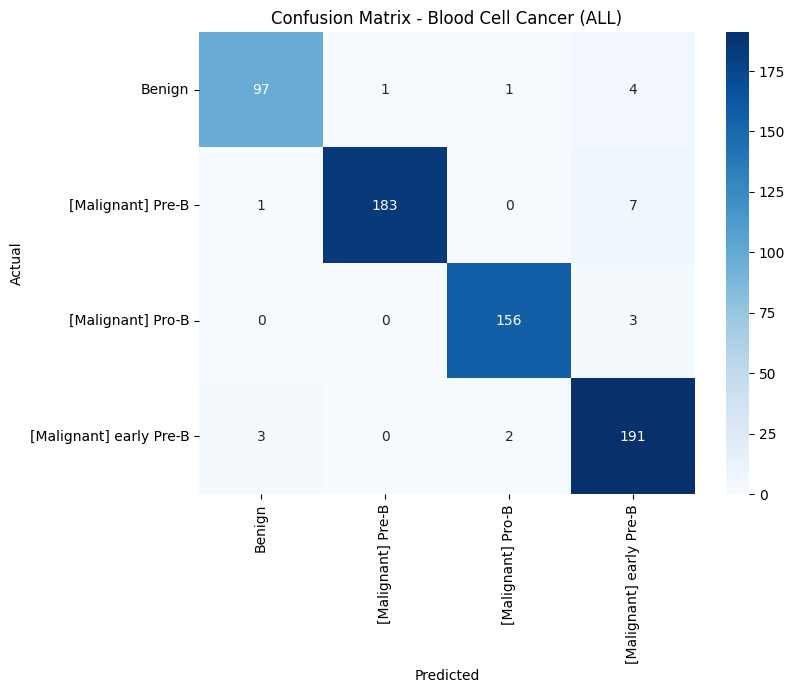

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. DATASET PATH
# ===============================
data_dir  = "Blood cell Cancer [ALL]" 

class_names = sorted(os.listdir(data_dir))
print("Classes found:", class_names)

# ===============================
# 2. LOAD IMAGE PATHS & LABELS
# ===============================
image_paths = []
labels = []

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    for img_name in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img_name))
        labels.append(idx)

image_paths = np.array(image_paths)
labels = np.array(labels)

print(f"Total images: {len(image_paths)}")

# ===============================
# 3. TRAIN-TEST SPLIT (80:20)
# ===============================
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Training samples: {len(X_train_paths)}")
print(f"Testing samples: {len(X_test_paths)}")

# ===============================
# 4. IMAGE LOADING FUNCTION
# ===============================
def load_images(image_paths, img_size=(224, 224)):
    images = []
    for path in image_paths:
        img = tf.keras.preprocessing.image.load_img(path, target_size=img_size)
        img = tf.keras.preprocessing.image.img_to_array(img)
        images.append(img)
    return np.array(images)

# Load images
X_train = load_images(X_train_paths)
X_test = load_images(X_test_paths)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# ===============================
# 5. MOBILENETV2 FEATURE EXTRACTOR
# ===============================
print("\nExtracting deep features using MobileNetV2...")

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # IMPORTANT for stability

feature_extractor = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D()
])

train_features = feature_extractor.predict(X_train, batch_size=32, verbose=1)
test_features = feature_extractor.predict(X_test, batch_size=32, verbose=1)

print("Train features shape:", train_features.shape)
print("Test features shape:", test_features.shape)

# ===============================
# 6. FEATURE SCALING
# ===============================
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# ===============================
# 7. RANDOM FOREST CLASSIFIER
# ===============================
print("\nTraining Random Forest classifier...")

rf_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(train_features, y_train)

# ===============================
# 8. PREDICTION & EVALUATION
# ===============================
y_pred = rf_classifier.predict(test_features)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nModel Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# ===============================
# 9. CONFUSION MATRIX
# ===============================
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Blood Cell Cancer (ALL)")
plt.show()


In [15]:
import joblib

# Save Random Forest model
joblib.dump(rf_classifier, "rf_classifier.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save class names
joblib.dump(class_names, "class_names.pkl")

print("✅ Random Forest, Scaler, and Class Names saved!")

✅ Random Forest, Scaler, and Class Names saved!
